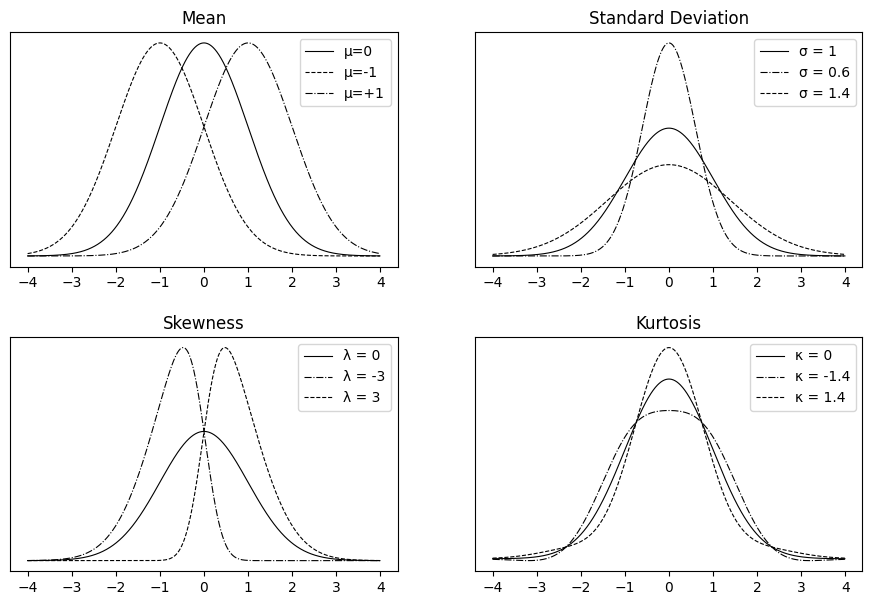

In [1]:
#PRINCIPAL MOMENT DISTRIBUTIONS

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, skewnorm
from statsmodels.sandbox.distributions.extras import pdf_mvsk

mu = 0
sigma = 1
skew = 0

x = np.arange(-4*sigma,4*sigma,0.01)
fig,ax = plt.subplots(2,2)
fig.set_figheight(7), fig.set_figwidth(11)
fig.subplots_adjust(hspace = 0.3)
ax[0,0].set_title("Mean")
ax[0,1].set_title("Standard Deviation")
ax[1,0].set_title("Skewness")
ax[1,1].set_title("Kurtosis");

ax[0,0].get_yaxis().set_visible(False), ax[0,1].get_yaxis().set_visible(False), ax[1,0].get_yaxis().set_visible(False), ax[1,1].get_yaxis().set_visible(False)
ax[0,0].plot(x,norm.pdf(x,mu,sigma),"k-",linewidth = 0.8)
ax[0,0].plot(x,norm.pdf(x,mu-1,sigma),"k--",linewidth = 0.8)
ax[0,0].plot(x,norm.pdf(x,mu+1,sigma),"k-.",linewidth = 0.8)
ax[0,0].legend(["μ=0","μ=-1","μ=+1"],loc = "upper right")

ax[0,1].plot(x,norm.pdf(x,mu,sigma),"k-",linewidth = 0.8)
ax[0,1].plot(x,norm.pdf(x,mu,sigma-0.4),"k-.",linewidth = 0.8)
ax[0,1].plot(x,norm.pdf(x,mu,sigma+0.4),"k--",linewidth = 0.8)
ax[0,1].legend(["σ = 1","σ = 0.6","σ = 1.4"],loc = "upper right")

ax[1,0].plot(x,skewnorm.pdf(x,skew),"k-",linewidth = 0.8)
ax[1,0].plot(x,skewnorm.pdf(x,skew-3) ,"k-.",linewidth = 0.8)
ax[1,0].plot(x,skewnorm.pdf(x,skew+3),"k--",linewidth = 0.8)
ax[1,0].legend(["λ = 0","λ = -3","λ = 3"],loc = "upper right")

positive = pdf_mvsk([0, 1, 0, 1.4])
negative = pdf_mvsk([0, 1, 0, -1.4])
ax[1,1].plot(x,norm.pdf(x),"k-",linewidth = 0.8)
ax[1,1].plot(x,negative(x),"k-.",linewidth = 0.8)
ax[1,1].plot(x,positive(x),"k--",linewidth = 0.8)
ax[1,1].legend(["κ = 0","κ = -1.4","κ = 1.4"],loc = "upper right");

In [2]:
#X PERIOD ARIMA

import pandas as pd
from pandas import DataFrame, Series
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

#INPUTS
symbol = "SPY"
period = 9 #no. days to forecast
lookback = "1y" #period to analyse; one of: [1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max]
t_days = 252 #number of trading days in a year

#COLLECT
df = DataFrame(yf.Ticker(symbol).history(period = lookback, interval = "1d")["Close"])
df["Return"] = np.log(df["Close"]/df["Close"].shift(1)) #daily log returns
df = df.asfreq("B")

#ARIMA
arima = sm.tsa.arima.ARIMA(df["Return"].asfreq("B"), order = (1,1,1), enforce_stationarity = False)
res = arima.fit(method_kwargs = {"maxiter": 300})
fore = res.forecast(steps = period)
agg_return = fore.values.mean()*t_days
print(f"ARIMA Forecast (annualised): {"{:.2%}".format(agg_return)}\n"
      f"Return over last {lookback} (annualised): {"{:.2%}".format(df["Return"].mean()*t_days)}")

ARIMA Forecast (annualised): 12.43%
Return over last 1y (annualised): 12.44%
